# Scraping Terrenos — Processed to Gold

Transforma `data/processed/scraping_manual/total_land_cantabria_outliers.csv` en el gold dataset `data/gold/final_land_scraping.csv` listo para modelado ML.

**Pipeline:**
1. Carga del dataset (sobre una copia del archivo original)
2. Filtrado de categorías de suelo con pocos registros
3. Exclusión de features con data leakage
4. Log-transformación del target (`log_precio`)
5. Target encoding de `municipio`
6. One-hot encoding de `tipo_suelo`
7. Conversión de booleanos a enteros
8. Exportación al gold layer (sobreescribe el archivo en cada ejecución)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Carga del dataset

Se carga el archivo procesado y se trabaja sobre una copia para no modificar el original.

In [ ]:
df_raw = pd.read_csv('../../data/processed/scraping_manual/total_land_cantabria_outliers.csv', sep=';')
df = df_raw.copy()

print(f'Shape inicial: {df.shape}')
df.head(3)

In [ ]:
print('Tipos de dato:')
print(df.dtypes)
print()
print('Nulos:')
print(df.isnull().sum())

Tipos de dato:
titulo                      object
municipio                   object
precio_eur                   int64
superficie_m2              float64
tipo_suelo                  object
vendido_con_descuento         bool
es_urbano_o_urbanizable       bool
precio_m2                  float64
dtype: object

Nulos:
titulo                     0
municipio                  0
precio_eur                 0
superficie_m2              0
tipo_suelo                 0
vendido_con_descuento      0
es_urbano_o_urbanizable    0
precio_m2                  0
dtype: int64


## 2. Filtrado de categorías de suelo con pocos registros

Se analiza la distribución de `tipo_suelo` para identificar categorías con muestra insuficiente para modelar.

Registros por categoría de suelo:
tipo_suelo
Urbano (solar)    452
Urbanizable       239
No urbanizable    133
Industrial          4
Name: count, dtype: int64


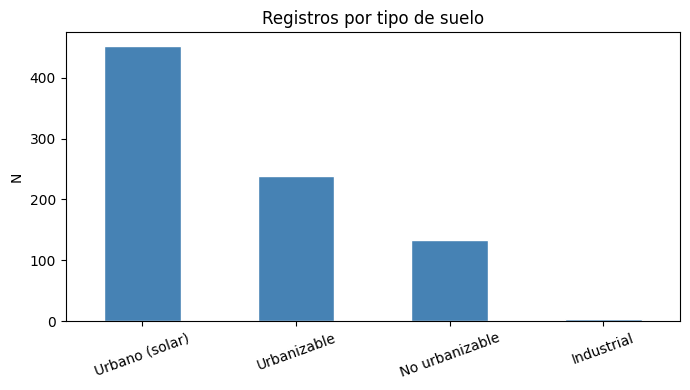

In [ ]:
conteo_tipo_suelo = df['tipo_suelo'].value_counts()
print('Registros por categoría de suelo:')
print(conteo_tipo_suelo)

fig, ax = plt.subplots(figsize=(7, 4))
conteo_tipo_suelo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Registros por tipo de suelo')
ax.set_xlabel('')
ax.set_ylabel('N')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# Solo 'Industrial' tiene registros insuficientes (4 observaciones).
# 'No urbanizable' tiene 133 registros — muestra adecuada, se conserva.
# Umbral: se eliminan categorías con menos de 10 registros.

UMBRAL_MIN = 10
categorias_validas = conteo_tipo_suelo[conteo_tipo_suelo >= UMBRAL_MIN].index.tolist()
categorias_eliminadas = conteo_tipo_suelo[conteo_tipo_suelo < UMBRAL_MIN].index.tolist()

print(f'Categorías conservadas: {categorias_validas}')
print(f'Categorías eliminadas (< {UMBRAL_MIN} registros): {categorias_eliminadas}')

df = df[df['tipo_suelo'].isin(categorias_validas)].copy()
print(f'\nShape tras filtrado: {df.shape}')

Categorías conservadas: ['Urbano (solar)', 'Urbanizable', 'No urbanizable']
Categorías eliminadas (< 10 registros): ['Industrial']

Shape tras filtrado: (824, 8)


## 3. Exclusión de features con data leakage

- **`precio_m2`**: derivada directamente del target (`precio_eur / superficie_m2`). Usarla como feature introduce data leakage — el modelo aprendería a invertir la fórmula en lugar de aprender patrones reales.
- **`titulo`**: texto libre con barrio y municipio. El municipio ya está capturado en `municipio`. Procesarlo requeriría NLP fuera del alcance de este pipeline.

In [ ]:
cols_excluir = ['precio_m2', 'titulo']
df = df.drop(columns=cols_excluir)

print(f'Columnas tras exclusión: {df.columns.tolist()}')

Columnas tras exclusión: ['municipio', 'precio_eur', 'superficie_m2', 'tipo_suelo', 'vendido_con_descuento', 'es_urbano_o_urbanizable']


## 4. Log-transformación del target

In [ ]:
df['log_precio'] = np.log(df['precio_eur'])

print(f'Target: log_precio')
print(df['log_precio'].describe())

Target: log_precio
count    686.000000
mean      11.471027
std        0.666520
min        8.779557
25%       11.082143
50%       11.551371
75%       11.951180
max       12.594731
Name: log_precio, dtype: float64


## 5. Target encoding de `municipio`

`municipio` tiene 35 categorías con distribución muy desigual (de 1 a 133 observaciones por municipio). One-hot encoding generaría columnas casi vacías. Se aplica **target encoding**: cada municipio se sustituye por la media de `log_precio` de ese municipio calculada sobre el dataset completo.

> **Nota**: este encoding se calcula sobre todos los datos. En el notebook de ML, el target encoding debe recalcularse dentro de cada fold de cross-validation para evitar leakage.

In [ ]:
target_encoding_municipio = df.groupby('municipio')['log_precio'].mean()

print('Target encoding por municipio (log_precio medio):')
print(target_encoding_municipio.sort_values(ascending=False).to_string())

Target encoding por municipio (log_precio medio):
municipio
Ruiloba                   12.153392
Comillas                  11.897053
Santillana del Mar        11.870161
Astillero                 11.842741
Ribamontán al Mar         11.837144
Santander                 11.725353
Santa Cruz de Bezana      11.673371
Viveda                    11.660751
Marina de Cudeyo          11.659435
Mazcuerras                11.644721
Camargo                   11.619344
Piélagos                  11.610156
Villaescusa               11.574228
Miengo                    11.569733
Suances                   11.522572
Ribamontán al Monte       11.519502
Polanco                   11.516944
Medio Cudeyo              11.505206
Reocín                    11.408350
Alfoz de Lloredo          11.403934
Cabezón de la Sal         11.394038
Torrelavega               11.368141
Penagos                   11.287800
Bareyo                    11.286001
Castañeda                 11.246579
Cartes                    11.232769
Udía

In [ ]:
df['municipio_encoded'] = df['municipio'].map(target_encoding_municipio)

print(f'Nulos en municipio_encoded: {df["municipio_encoded"].isnull().sum()}')
df = df.drop(columns=['municipio'])

Nulos en municipio_encoded: 0


## 6. One-hot encoding de `tipo_suelo`

In [ ]:
dummies_suelo = pd.get_dummies(df['tipo_suelo'], prefix='tipo_suelo', drop_first=False, dtype=int)
print('Dummies creadas:')
print(dummies_suelo.sum())

df = pd.concat([df.drop(columns=['tipo_suelo']), dummies_suelo], axis=1)

Dummies creadas:
tipo_suelo_No urbanizable    126
tipo_suelo_Urbanizable       210
tipo_suelo_Urbano (solar)    350
dtype: int64


## 7. Conversión de booleanos a enteros

In [ ]:
cols_bool = ['vendido_con_descuento', 'es_urbano_o_urbanizable']
df[cols_bool] = df[cols_bool].astype(int)

print('Distribución de variables binarias:')
print(df[cols_bool].sum())

Distribución de variables binarias:
vendido_con_descuento       27
es_urbano_o_urbanizable    560
dtype: int64


## 8. Dataset gold final

In [ ]:
print('Columnas del gold dataset:')
print(df.columns.tolist())
print(f'\nShape final: {df.shape}')
df.describe()

Columnas del gold dataset:
['precio_eur', 'superficie_m2', 'vendido_con_descuento', 'es_urbano_o_urbanizable', 'log_precio', 'municipio_encoded', 'tipo_suelo_No urbanizable', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano (solar)']

Shape final: (686, 9)


,precio_eur,superficie_m2,vendido_con_descuento,es_urbano_o_urbanizable,log_precio,municipio_encoded,tipo_suelo_No urbanizable,tipo_suelo_Urbanizable,tipo_suelo_Urbano (solar)
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,115614.825073,3523.879009,0.039359,0.816327,11.471027,11.471027,0.183673,0.306122,0.510204
std,64547.508007,3405.741354,0.194589,0.387500,0.666520,0.232437,0.387500,0.461218,0.500261
min,6500.000000,113.000000,0.000000,0.000000,8.779557,10.654492,0.000000,0.000000,0.000000
25%,65000.000000,1202.500000,0.000000,1.000000,11.082143,11.368141,0.000000,0.000000,0.000000
50%,103925.000000,2250.000000,0.000000,1.000000,11.551371,11.519502,0.000000,0.000000,1.000000
75%,155000.000000,4505.250000,0.000000,1.000000,11.951180,11.610156,0.000000,1.000000,1.000000
max,295000.000000,16270.000000,1.000000,1.000000,12.594731,12.153392,1.000000,1.000000,1.000000


In [ ]:
print('Nulos en el gold dataset:')
print(df.isnull().sum())

Nulos en el gold dataset:
precio_eur                   0
superficie_m2                0
vendido_con_descuento        0
es_urbano_o_urbanizable      0
log_precio                   0
municipio_encoded            0
tipo_suelo_No urbanizable    0
tipo_suelo_Urbanizable       0
tipo_suelo_Urbano (solar)    0
dtype: int64


In [ ]:
# Sobreescribe el archivo en cada ejecución (mode='w' por defecto en to_csv)
output_path = '../../data/gold/final_land_scraping.csv'
df.to_csv(output_path, index=False)

print(f'Gold dataset exportado a: {output_path}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

Gold dataset exportado a: ../../data/gold/final_land_scraping.csv
Filas: 686 | Columnas: 9
